# Trabajo Práctico 2: Armado de un esquema de aprendizaje automático

En el Trabajo Práctico final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`.   
El conjunto de datos a utilizar está en `("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")`.

Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

# Orientación general del Trabajo Práctico 2

En este trabajo práctico vamos a resolver un problema de **clasificación supervisada**.

El objetivo no es solamente entrenar modelos, sino recorrer el flujo completo de trabajo:

1. Comprender el problema y el dataset.
2. Identificar la variable objetivo.
3. Analizar si las clases están balanceadas.
4. Separar datos de entrenamiento y evaluación.
5. Entrenar modelos de clasificación.
6. Ajustar hiperparámetros con validación cruzada.
7. Evaluar los modelos con métricas apropiadas.
8. Comparar modelos y justificar una recomendación final.

A lo largo del trabajo vamos a intentar responder una pregunta central:

> ¿Qué modelo recomendaríamos usar para este problema y con qué evidencia lo justificaríamos?


# Evaluación con métricas

Para cada modelo evaluado deberíamos reportar, como mínimo:

- accuracy;
- precision;
- recall;
- F1-score;
- matriz de confusión.

Pero además debemos interpretar esos números.

Preguntas orientadoras:

1. ¿El modelo clasifica igual de bien ambas clases?
2. ¿Hay muchos falsos positivos?
3. ¿Hay muchos falsos negativos?
4. ¿Qué métrica parece más relevante para este problema?
5. ¿La accuracy alcanza para decidir o necesitamos mirar otras métricas?

Recordemos que, en problemas con clases desbalanceadas, la accuracy puede ocultar errores importantes.


# Análisis exploratorio mínimo

Antes de entrenar modelos, revisemos:

1. Tamaño del dataset.
2. Nombre y tipo de las variables.
3. Valores faltantes.
4. Distribución de la variable `TARGET`.
5. Posible desbalance de clases.

En particular, para `TARGET` deberíamos calcular:

```python
df["TARGET"].value_counts()
df["TARGET"].value_counts(normalize=True)
```

Si una clase aparece mucho más que la otra, la accuracy puede ser engañosa. En ese caso, deberemos mirar también precision, recall, F1-score y matriz de confusión.


## Antes de empezar: costo del error

Como el problema está relacionado con la aprobación de préstamos o créditos, no todos los errores tienen el mismo significado.

Conviene pensar desde el comienzo:

- **Falso positivo:** el modelo recomienda aprobar un préstamo que no debería aprobarse.
- **Falso negativo:** el modelo recomienda rechazar un préstamo que sí debería aprobarse.

Preguntas para tener presentes durante todo el trabajo:

- ¿Cuál de estos errores sería más costoso para el banco?
- ¿Cuál sería más perjudicial para el cliente?
- ¿Qué métrica nos ayudaría a controlar mejor cada tipo de error?


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold,  cross_val_score, cross_validate
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [3]:
# Carga del dataset
URL = "https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv"
loan_df = pd.read_csv(URL, comment="#")

loan_df.head()


,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106


### Diccionario de Variables
- TARGET: La variable objetivo. Suele ser binaria (0 o 1). Indica si el cliente incumplió con el pago (1) o si pagó puntualmente (0).

- LOAN: Monto del préstamo solicitado (en unidades monetarias).

- MORTDUE: Monto adeudado de la hipoteca existente (*Mortgage Due*).

- VALUE: Valor actual de la propiedad colocada como garantía.

- YOJ: Años en el trabajo actual (*Years on Job*).

- DEROG: Número de informes desfavorables o derogatorios (*Derogatory Reports*) en el historial crediticio (quiebras, demandas, etc.).

- DELINQ: Número de líneas de crédito morosas o delincuentes (*Delinquent Credit Lines*).

- CLAGE: Antigüedad de la línea de crédito más antigua en meses (*Age of Oldest Credit Line*).

- NINQ: Número de consultas de crédito recientes (*Number of Recent Credit Inquiries*). Esto mide qué tanto está buscando financiamiento el cliente.

- CLNO: Número de líneas de crédito activas que tiene el cliente (*Number of Credit Lines*).

- DEBTINC: Relación deuda-ingreso (*Debt-to-Income Ratio*). Expresado normalmente como un porcentaje (ej. 35.2 significa que el 35.2% de sus ingresos se van en pagar deudas).

### Exploración inicial del dataset

Exploramos el dataset para conocer las dimensiones, tipos de cada variables para conocer cuántas instancias y variables tenemos.

*   Elemento de la lista
*   Elemento de la lista



In [4]:
# Dimensiones del dataset
print(f"Filas: {loan_df.shape[0]}, Columnas: {loan_df.shape[1]}")
print()
print(loan_df.dtypes)


Filas: 1854, Columnas: 11

TARGET       int64
LOAN         int64
MORTDUE    float64
VALUE      float64
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object


Tenemos una vista rápida de cuántas instancias y variables hay, y qué tipo tiene cada columna. Todas son numéricas.

In [5]:
# Estadísticas descriptivas
loan_df.describe().round(2)

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00
mean,0.17,19111.76,76316.05,107321.09,8.90,0.19,0.32,180.30,1.13,21.86,34.57
std,0.37,11000.35,46227.03,56039.69,7.55,0.70,0.93,84.84,1.66,9.51,9.31
min,0.00,1700.00,5627.00,21144.00,0.00,0.00,0.00,0.49,0.00,0.00,0.84
25%,0.00,12000.00,48984.75,70787.25,3.00,0.00,0.00,116.97,0.00,16.00,29.43
50%,0.00,17000.00,67201.00,94198.00,7.00,0.00,0.00,174.97,1.00,21.00,35.36
75%,0.00,23900.00,93731.50,122976.25,13.00,0.00,0.00,232.26,2.00,27.00,39.36
max,1.00,89800.00,399412.00,512650.00,41.00,10.00,10.00,1168.23,13.00,65.00,144.19


Se detecta rangos muy dispares entre variables. Por ejemplo, VALUE y MORTDUE están en cientos de miles, mientras que DEROG y DELINQ tienen media cercana a 0. Esto anticipa la necesidad de escalar antes de usar SGDClassifier.


In [6]:
# Valores faltantes por columna
missing = pd.DataFrame({
    'Faltantes': loan_df.isnull().sum(),
    'Porcentaje (%)': (loan_df.isnull().mean() * 100).round(2)
})
print(missing)

         Faltantes  Porcentaje (%)
TARGET           0             0.0
LOAN             0             0.0
MORTDUE          0             0.0
VALUE            0             0.0
YOJ              0             0.0
DEROG            0             0.0
DELINQ           0             0.0
CLAGE            0             0.0
NINQ             0             0.0
CLNO             0             0.0
DEBTINC          0             0.0


El dataset no presenta valores faltantes.

Corrección de tipos

Se observan variables con valores enteros cargadas como reales. Estas variables representan conteos (números de líneas de crédito, de informes desfavorables, etc).


In [7]:
# Variables que deberían ser enteras pero cargaron como float
loan_df['YOJ']   = loan_df['YOJ'].astype(int)
loan_df['DEROG'] = loan_df['DEROG'].astype(int)
loan_df['DELINQ']= loan_df['DELINQ'].astype(int)
loan_df['CLNO']  = loan_df['CLNO'].astype(int)
loan_df['NINQ']  = loan_df['NINQ'].astype(int)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TARGET   1854 non-null   int64  
 1   LOAN     1854 non-null   int64  
 2   MORTDUE  1854 non-null   float64
 3   VALUE    1854 non-null   float64
 4   YOJ      1854 non-null   int64  
 5   DEROG    1854 non-null   int64  
 6   DELINQ   1854 non-null   int64  
 7   CLAGE    1854 non-null   float64
 8   NINQ     1854 non-null   int64  
 9   CLNO     1854 non-null   int64  
 10  DEBTINC  1854 non-null   float64
dtypes: float64(4), int64(7)
memory usage: 159.5 KB


Distribución absoluta:
TARGET
0    1545
1     309
Name: count, dtype: int64

Distribución relativa:
TARGET
0    0.833
1    0.167
Name: proportion, dtype: float64


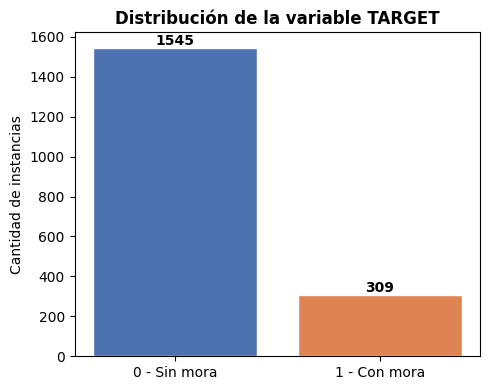

In [8]:
#Distribución de TARGET
print("Distribución absoluta:")
print(loan_df['TARGET'].value_counts())
print()
print("Distribución relativa:")
print(loan_df['TARGET'].value_counts(normalize=True).round(3))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(5, 4))
counts = loan_df['TARGET'].value_counts()
bars = ax.bar(
    ['0 - Sin mora', '1 - Con mora'],
    counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white'
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontweight='bold')
ax.set_title('Distribución de la variable TARGET', fontweight='bold')
ax.set_ylabel('Cantidad de instancias')
plt.tight_layout()
plt.show()

El dataset está desbalanceado: 83.3% con clase 0 (sin mora) y solo 16.7% clase 1 (con mora). Esto se utiliza para entender por qué el accuracy solo no alcanza como métrica. Un modelo que prediga siempre sin mora ya alcanzaría 83% de accuracy sin aprender nada.

Se analiza la distribución de las variables.

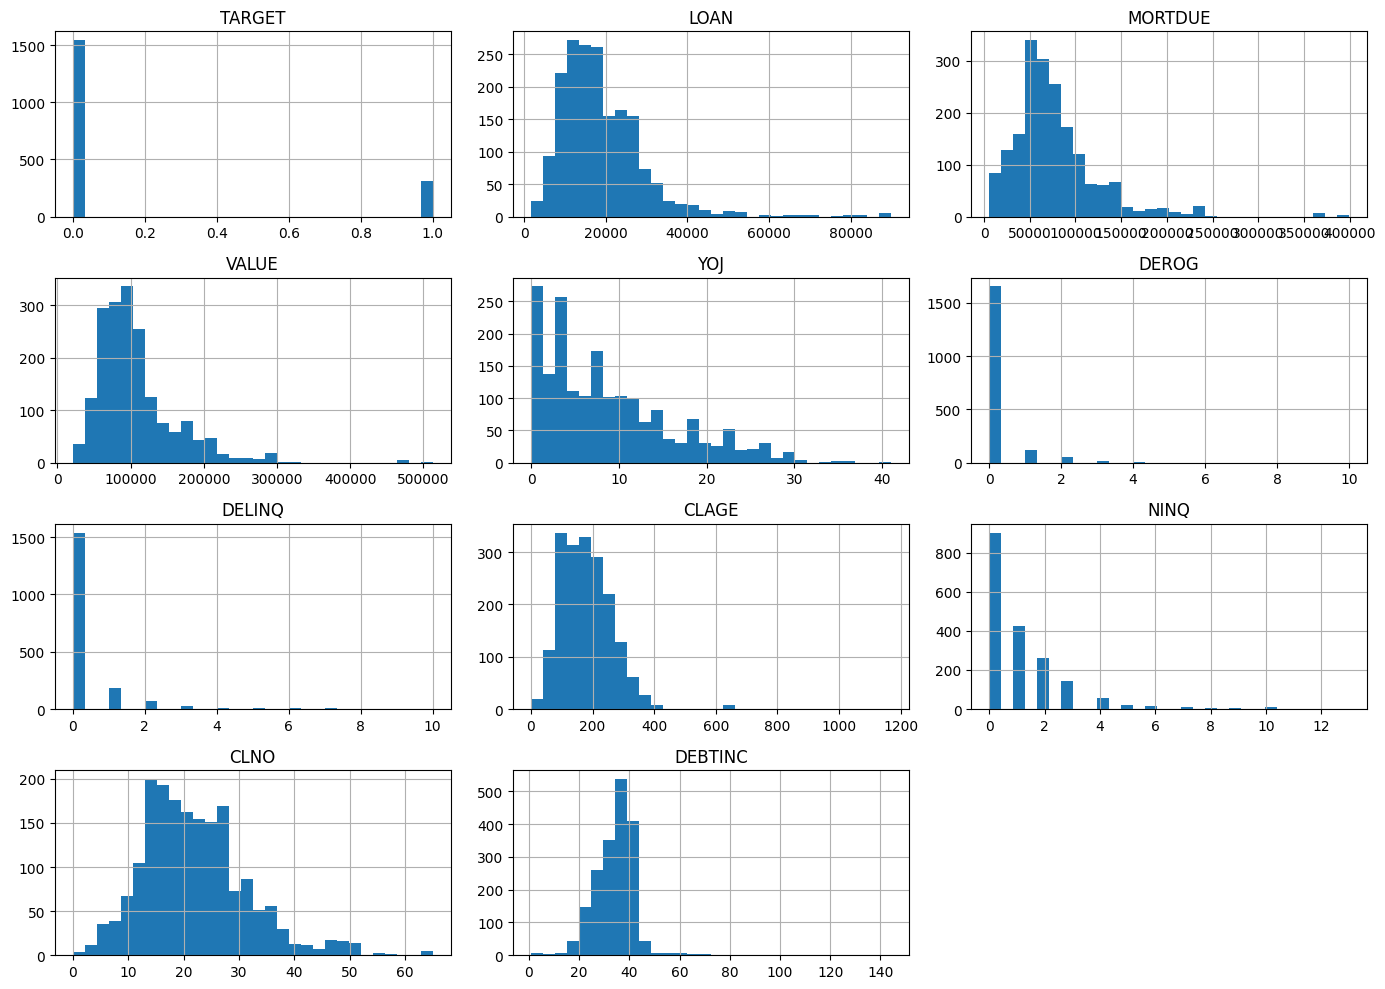

In [9]:
#Histogramas de todas las variables
loan_df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

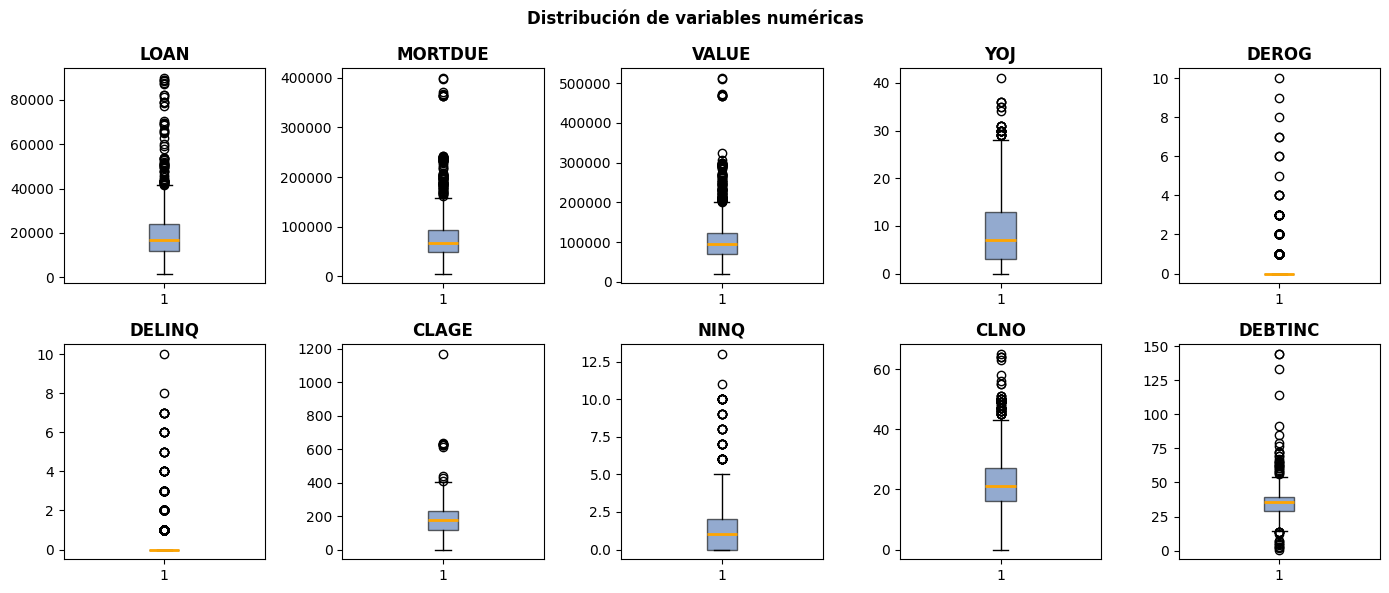

In [10]:
#Boxplots para observar outliers
features = ['LOAN','MORTDUE','VALUE','YOJ','DEROG','DELINQ','CLAGE','NINQ','CLNO','DEBTINC']

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(
        loan_df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor='#4C72B0', alpha=0.6),
        medianprops=dict(color='orange', linewidth=2)
    )
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Distribución de variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

Complementa los histogramas mostrando outliers concretos. LOAN, MORTDUE, VALUE y DEBTINC tienen valores extremos. Se confirma visualmente la diferencia de escala entre variables.

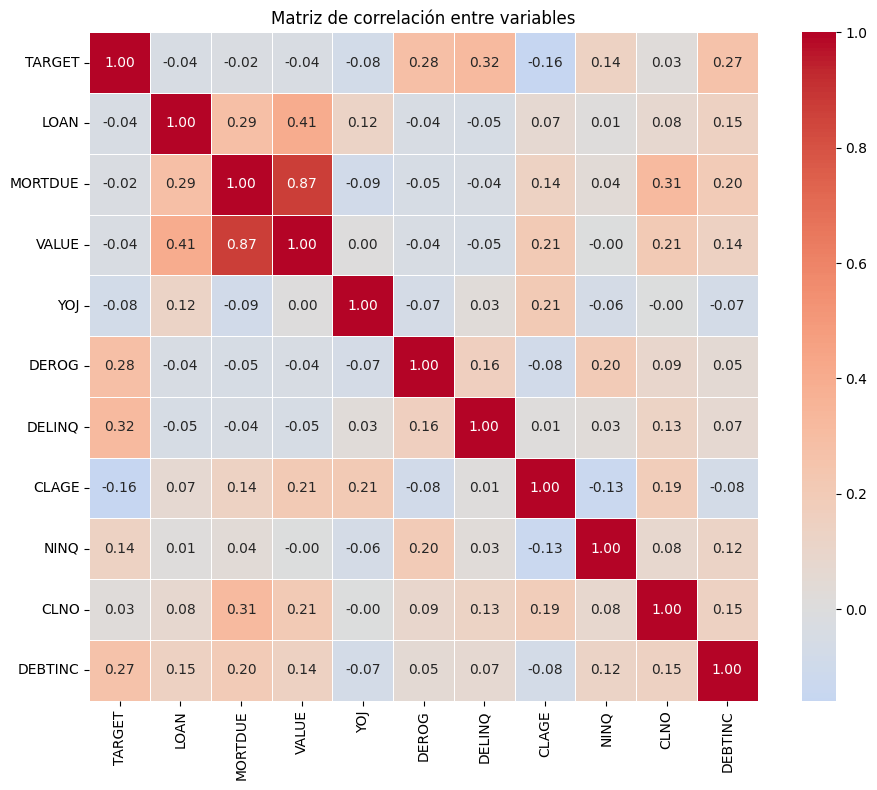

In [11]:
#Matriz de correlación entre features
corr_matrix = loan_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación entre variables")
plt.tight_layout()
plt.show()

Se observa correlación fuerte entre MORTDUE y VALUE (0.87 aprox), lo que tiene sentido, a mayor valor de propiedad, mayor deuda hipotecaria posible. También hay correlación entre VALUE y LOAN.

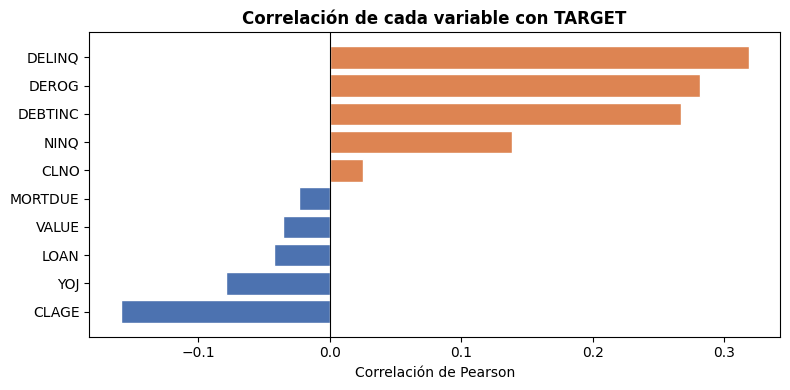

In [12]:
#Correlación individual con TARGET
corr_target = loan_df.corr()['TARGET'].drop('TARGET').sort_values()
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_target.values]

plt.figure(figsize=(8, 4))
plt.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con TARGET', fontweight='bold')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

Se observa qué variables tienen más relación lineal con TARGET. Las más relevantes son DELINQ (0.32), DEROG (0.28) y DEBTINC (0.27). Ninguna supera 0.33, lo que sugiere que las relaciones son débiles de forma individual y que un modelo no lineal como el árbol puede tener ventaja.

In [13]:
#División Train /Test
X = loan_df.iloc[:, 1:]   # features
y = loan_df['TARGET']     # etiqueta

# Reservar 20% para test
X_aux, X_test, y_aux, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# Del 80% restante, 20% para validación → 16% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_aux, y_aux, test_size=0.2, stratify=y_aux, random_state=0
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_val:  ", X_val.shape)
print("Tamaño de X_test: ", X_test.shape)

Tamaño de X_train: (1186, 10)
Tamaño de X_val:   (297, 10)
Tamaño de X_test:  (371, 10)


### Conclusiones del análisis exploratorio

Se encontró que:

- Dataset de 1854 instancias, sin valores faltantes, todas variables numéricas.
- Desbalance: 83.3% clase 0 vs 16.7% clase 1, el accuracy solo es engañoso.
- Escalas muy distintas entre variables, es necesario usar StandardScaler antes del SGDClassifier.
- Multicolinealidad entre MORTDUE y VALUE.
- Las variables con mayor correlación con TARGET son DELINQ, DEROG y DEBTINC, pero con relaciones lineales individuales débiles.
- Variables como DEROG y DELINQ concentran muchos ceros con pocos valores altos.

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

**1. ¿De qué se trata el conjunto de datos?**

Es un dataset de solicitudes de préstamos bancarios. Cada fila representa una persona que pidió un préstamo, con sus características financieras.


**2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?**

La variable objetivo es TARGET. Toma valores 0 (prestamos fue pagado sin problemas) o 1 (el prestamo entró en mora/default).

**3. ¿Qué información (atributos) hay disponible para hacer la predicción?**

Atributos disponibles:

- LOAN: monto del préstamo solicitado.
- MORTDUE: deuda hipotecaria pendiente.
- VALUE: valor de la propiedad.
- YOJ: años en el trabajo actual.
- DEROG: número de registros derogatorios (manchas crediticias graves).
- DELINQ: número de líneas de crédito con mora.
- CLAGE: antigüedad de la línea de crédito más antigua (meses).
- NINQ: número de consultas de crédito recientes.
- CLNO: número de líneas de crédito activas.
- DEBTINC: ratio deuda/ingreso.


**4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?**

A partir del análisis exploratorio, las variables con mayor correlación con TARGET son DELINQ (0.32), DEROG (0.28) (historial de incumplimientos) y DEBTINC (0.27) (cuánta deuda tiene respecto a su ingreso). Un cliente con historial de incumplimientos previos, manchas crediticias y alta carga de deuda sobre sus ingresos tiene un perfil de riesgo  más elevado.

## Preguntas orientadoras para el análisis del dataset


**1. ¿De qué se trata este conjunto de datos?**

Es un dataset de solicitudes de préstamos bancarios. Cada fila representa un cliente que pidió un préstamos, con sus características financieras e historial crediticio.


**2. ¿Qué representa la variable `TARGET`?**

La variable TARGET indica si el cliente entró en mora o no. Es una variable binaria: toma valor 0 o 1.


**3. ¿Qué significa la clase `0` y qué significa la clase `1`?**

Significado de clases:

- Clase 0: el préstamo fue pagado correctamente, sin incumplimiento.
- Clase 1: el cliente entró en mora, es decir, no cumplió con los pagos del préstamo.


**4. ¿Cuál es el problema que intenta resolver el banco?**

El banco busca predecir, antes de otorgar el préstamo, si el cliente va a incumplir o no. Esto le permite tomar mejores decisiones de riesgo crediticio. Un falso negativo (aprobar a alguien que entrará en mora) tiene un costo financiero directo para el banco, mientras que un falso positivo (rechazar a alguien que hubiera pagado) representa un costo de oportunidad. Eso define qué métrica priorizar más adelante.

**5. ¿Qué variables predictoras tenemos disponibles?**

Variables predictoras disponibles: diez variables numéricas: LOAN (monto solicitado), MORTDUE (deuda hipotecaria pendiente), VALUE (valor de la propiedad), YOJ (años en el trabajo actual), DEROG (registros derogatorios), DELINQ (líneas de crédito en mora), NINQ (consultas crediticias recientes), CLNO (cantidad de líneas de crédito), DEBTINC (ratio deuda/ingreso) y CLAGE (antigüedad de la línea de crédito más antigua).


**6. ¿Qué variables creemos que podrían ser más importantes?**

Variables que podrían ser importantes, de acuerdo al gráfico de correlaciones son: DELINQ, DEROG, y DEBTINC, intuitivamente indica que alguien con historial de mora, manchas crediticias y alta relación deuda/ingreso es un perfil de mayor riesgo.


**7. ¿Hay variables que podrían estar relacionadas entre sí?**

Las variables que podrían estar correlacionadas entre sí, son MORTDUE y VALUE, porque la deuda hipotecaria depende del valor de la propiedad, DELINQ y DEROG también porque ambas reflejan el historial de incumplimientos, solo que en distintos niveles de gravedad. Esta correlación entre predictores se llama multicolinealidad, que puede afectar a los modelos lineales, aunque no a los árboles de decisión.


**8. ¿Qué información adicional nos gustaría tener para comprender mejor el problema?**

La información adicional que estaría bueno tener, sería el ingreso absoluto del cliente (no solo el ratio deuda / ingreso), el tipo de préstamo, la tasa de interés ofrecida, y si el cliente tiene otras deudas fuera de la hipoteca. También seria útil saber si hay sesgo temporal en los datos, es decir si las solicitudes más antiguas tienen más probabilidad de haber entrado en mora por tener más tiempo para hacerlo.


# Modelo lineal con SGDClassifier

En esta parte vamos a usar un clasificador lineal entrenado mediante descenso de gradiente estocástico.

Antes de evaluar resultados, respondamos:

**1. ¿Qué significa que sea un modelo lineal?**

Significa que el modelo asume que las clases pueden separarse con un hiperplano (una línea recta en 2D) en el espacio de features. La decisión se basa en una combinación lineal de las variables: `y = w₀ + w₁x₁ + w₂x₂ + ...`, donde cada coeficiente `wᵢ` indica el peso de cada feature.

Esto lo hace muy interpretable, pero también limitado: si la relación real entre las variables y el target es curva o tiene interacciones complejas, el modelo no podrá capturarlas. Por eso más adelante se compara con un árbol de decisión, que sí puede modelar relaciones no lineales.

**2. ¿Qué función de pérdida estamos usando?**

Por defecto, el `SGDClassifier` usa `loss='hinge'`, que corresponde a una SVM lineal. Esta función penaliza las predicciones que caen del lado incorrecto del margen de separación.

En el GridSearch también se van a explorar otras funciones de pérdida como `log_loss` (equivalente a regresión logística, produce probabilidades) y `modified_huber` (más robusta ante outliers y también permite obtener probabilidades).


**3. ¿Qué hiperparámetros aparecen en la documentación?**

Los principales son:

- `loss`: función de pérdida (`hinge`, `log_loss`, `modified_huber`, entre otras).
- `penalty`: tipo de regularización (`l2`, `l1`, `elasticnet`).
- `alpha`: constante que multiplica el término de regularización. A mayor valor, más fuerte la penalización.
- `learning_rate`: estrategia de actualización de la tasa (`constant`, `optimal`, `invscaling`, `adaptive`).
- `eta0`: tasa de aprendizaje inicial.
- `max_iter`: número máximo de épocas sobre los datos de entrenamiento.
- `tol`: criterio de parada (si la mejora es menor que `tol`, se detiene).
- `class_weight`: permite asignar mayor peso a clases minoritarias, útil en datasets desbalanceados como este.
- `random_state`: semilla para reproducibilidad.

**4. ¿Qué valores toma el modelo por defecto?**

La configuración por defecto del SGDClassifier es:

- `loss='hinge'`: función de pérdida SVM lineal.
- `penalty='l2'`: regularización L2.
- `alpha=0.0001`: intensidad de la regularización.
- `learning_rate='optimal'`: tasa calculada automáticamente según alpha y loss.
- `eta0=0.01` : tasa de aprendizaje inicial (referencia para algunos schedulers).
- `max_iter=1000`:  máximo de épocas sobre los datos.
- `tol=0.001`: criterio de parada.
- `class_weight=None`: todas las clases con el mismo peso.

Un detalle importante para este problema: `class_weight=None` significa que el modelo trata ambas clases por igual. Dado el desbalance 83/17 del dataset, esto puede hacer que el modelo ignore casi por completo la clase 1 (mora), como se verá en los resultados.


**5. ¿Por qué la tasa de aprendizaje y la regularización pueden afectar el resultado?**

La tasa de aprendizaje controla el tamaño de cada paso al actualizar los pesos durante el entrenamiento:
- Si es demasiado alta, el algoritmo puede oscilar y no converger.
- Si es demasiado baja, el aprendizaje es muy lento y puede quedarse en un mínimo local.
- `learning_rate='optimal'` calcula automáticamente una tasa adaptada al valor de `alpha` y al tipo de `loss`, y suele ser una buena opción de partida.

La regularización (`alpha`) penaliza coeficientes grandes para evitar que el modelo se ajuste demasiado al ruido del entrenamiento (overfitting):
- Con `alpha` alto, los coeficientes son pequeños y estables: el modelo captura la tendencia general pero puede subajustar.
- Con `alpha` bajo, el modelo tiene más libertad para ajustarse a los datos, pero puede memorizar el ruido.

Ambos hiperparámetros se van a explorar en el GridSearch para encontrar la combinación que mejor generaliza.



## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

In [29]:
# Escalamos los datos
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [30]:
# Entrenamos del modelo
model = SGDClassifier(random_state=42)

model.fit(X_train_scaled, y_train)

SGDClassifier(random_state=42)

In [31]:
# Predicciones
y_train_predict = model.predict(X_train_scaled)
y_val_predict = model.predict(X_val_scaled)

In [40]:
# Función para evaluar métricas
def evaluar_modelo(y_true, y_pred, nombre):
    print(f"--- Métricas {nombre} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1-score :", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print()

In [36]:
# Evaluación del modelo
evaluar_modelo(y_train, y_train_predict, "Train")
evaluar_modelo(y_val, y_val_predict, "Validation")

--- Métricas Train ---
Accuracy : 0.817
Precision: 0.4469
Recall   : 0.404
F1-score : 0.4244

--- Métricas Validation ---
Accuracy : 0.835
Precision: 0.5
Recall   : 0.5306
F1-score : 0.5149



In [38]:
# Reporte completo por clase
target_names = ['Clase 0 - Sin mora', 'Clase 1 - Con mora']

print("Classification Report - Train")
print(classification_report(
    y_train,
    y_train_predict,
    target_names=target_names,
    zero_division=0
))

print("Classification Report - Validation")
print(classification_report(
    y_val,
    y_val_predict,
    target_names=target_names,
    zero_division=0
))

Classification Report - Train
                    precision    recall  f1-score   support

Clase 0 - Sin mora       0.88      0.90      0.89       988
Clase 1 - Con mora       0.45      0.40      0.42       198

          accuracy                           0.82      1186
         macro avg       0.66      0.65      0.66      1186
      weighted avg       0.81      0.82      0.81      1186

Classification Report - Validation
                    precision    recall  f1-score   support

Clase 0 - Sin mora       0.91      0.90      0.90       248
Clase 1 - Con mora       0.50      0.53      0.51        49

          accuracy                           0.84       297
         macro avg       0.70      0.71      0.71       297
      weighted avg       0.84      0.84      0.84       297



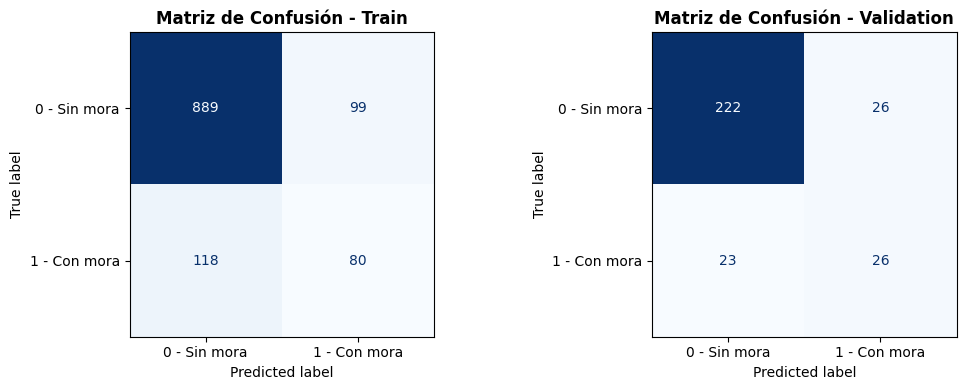

In [41]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_predict,
    display_labels=['0 - Sin mora', '1 - Con mora'],
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)

axes[0].set_title("Matriz de Confusión - Train", fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_predict,
    display_labels=['0 - Sin mora', '1 - Con mora'],
    cmap='Blues',
    ax=axes[1],
    colorbar=False
)

axes[1].set_title("Matriz de Confusión - Validation", fontweight='bold')

plt.tight_layout()
plt.show()

El modelo SGDClassifier con hiperparámetros por defecto obtuvo un accuracy de 0.817 en entrenamiento y 0.835 en validación. A simple vista parece un resultado aceptable, pero como el dataset está desbalanceado, el accuracy por sí solo no alcanza para evaluar bien el modelo.

Mirando la clase 1, que representa a los clientes con mora, el modelo tuvo en validación una precision de 0.50, un recall de 0.5306 y un F1-score de 0.5149. Esto significa que logró detectar aproximadamente el 53% de los casos reales de mora, aunque todavía dejó sin identificar 23 clientes con mora real.

En conclusión, el modelo por defecto no ignora completamente la clase minoritaria, pero su desempeño todavía es moderado. Detecta parte de los casos de mora, aunque sigue cometiendo falsos negativos, que en un problema de riesgo crediticio son errores importantes.

# Búsqueda de hiperparámetros con validación cruzada

Ahora no queremos quedarnos con una sola configuración del modelo.

Vamos a probar varias combinaciones de hiperparámetros y evaluarlas mediante validación cruzada.

Cuando analicemos los resultados de `GridSearchCV`, no miremos solamente el mejor score. También observemos:

1. `best_params_`: mejor combinación de hiperparámetros.
2. `best_score_`: mejor desempeño promedio en validación cruzada.
3. `mean_test_score`: media del score en validación.
4. `std_test_score`: variabilidad entre folds.
5. `mean_train_score`: desempeño promedio en entrenamiento, si está disponible.

Una configuración con media alta y desviación estándar baja suele ser más estable que una configuración con media alta pero gran variabilidad.


### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [42]:
# Grilla de hiperparámetros
param_grid = [
    {
        'loss': ['hinge', 'log_loss', 'modified_huber', 'perceptron'],
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'learning_rate': ['optimal'],
        'class_weight': [None, 'balanced']
    },
    {
        'loss': ['hinge', 'log_loss', 'modified_huber', 'perceptron'],
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'learning_rate': ['constant', 'invscaling', 'adaptive'],
        'eta0': [0.001, 0.01, 0.1],
        'class_weight': [None, 'balanced']
    }
]

In [43]:
# GridSearchCV con 5-fold cross-validation
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=SGDClassifier(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=stratified_kfold,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SGDClassifier(random_state=42), n_jobs=-1,
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1],
                          'class_weight': [None, 'balanced'],
                          'learning_rate': ['optimal'],
                          'loss': ['hinge', 'log_loss', 'modified_huber',
                                   'perceptron']},
                         {'alpha': [0.0001, 0.001, 0.01, 0.1],
                          'class_weight': [None, 'balanced'],
                          'eta0': [0.001, 0.01, 0.1],
                          'learning_rate': ['constant', 'invscaling',
                                            'adaptive'],
                          'loss': ['hinge', 'log_loss', 'modified_huber',
                                   'perceptron']}],
             return_train_score=True, scoring='accuracy')

In [44]:
# Mejor combinación encontrada
print("Mejor combinación de hiperparámetros:")
print(grid_search.best_params_)

print()
print("Mejor accuracy promedio en validación cruzada:")
print(round(grid_search.best_score_, 4))

Mejor combinación de hiperparámetros:
{'alpha': 0.001, 'class_weight': None, 'learning_rate': 'optimal', 'loss': 'hinge'}

Mejor accuracy promedio en validación cruzada:
0.8668


In [52]:
# Tabla con acurracy promedio y varianza para todas las configuraciones
resultados = pd.DataFrame(grid_search.cv_results_)

resultados['var_test_score'] = resultados['std_test_score'] ** 2

tabla_resultados = resultados[[
    'param_loss',
    'param_alpha',
    'param_learning_rate',
    'param_eta0',
    'param_class_weight',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'var_test_score',
    'rank_test_score'
]].sort_values(by='mean_test_score', ascending=False)

tabla_resultados.columns = [
    'Loss',
    'Alpha',
    'Learning Rate',
    'Eta0',
    'Class Weight',
    'Accuracy Train Promedio',
    'Accuracy Validación Promedio',
    'Desvío Accuracy Validación',
    'Varianza Accuracy Validación',
    'Ranking'
]

tabla_resultados.head(10).round(4)

,Loss,Alpha,Learning Rate,Eta0,Class Weight,Accuracy Train Promedio,Accuracy Validación Promedio,Desvío Accuracy Validación,Varianza Accuracy Validación,Ranking
8,hinge,0.0010,optimal,NaN,None,0.8615,0.8668,0.0166,0.0003,1
34,modified_huber,0.0001,constant,0.001,None,0.8615,0.8659,0.0172,0.0003,2
106,modified_huber,0.0010,constant,0.001,None,0.8615,0.8659,0.0172,0.0003,2
60,hinge,0.0001,invscaling,0.100,None,0.8647,0.8651,0.0167,0.0003,4
196,hinge,0.0100,adaptive,0.010,None,0.8651,0.8651,0.0167,0.0003,4
52,hinge,0.0001,adaptive,0.010,None,0.8666,0.8651,0.0183,0.0003,6
64,hinge,0.0001,adaptive,0.100,None,0.8657,0.8651,0.0183,0.0003,6
206,modified_huber,0.0100,invscaling,0.100,None,0.8634,0.8651,0.0169,0.0003,6
136,hinge,0.0010,adaptive,0.100,None,0.8655,0.8651,0.0183,0.0003,6
124,hinge,0.0010,adaptive,0.010,None,0.8664,0.8651,0.0183,0.0003,6


In [53]:
# Mejor modelo
best_model = grid_search.best_estimator_

y_train_predict_best = best_model.predict(X_train_scaled)
y_val_predict_best = best_model.predict(X_val_scaled)

evaluar_modelo(y_train, y_train_predict_best, "Train - Mejor modelo")
evaluar_modelo(y_val, y_val_predict_best, "Validation - Mejor modelo")

--- Métricas Train - Mejor modelo ---
Accuracy : 0.8693
Precision: 0.9388
Recall   : 0.2323
F1-score : 0.3725

--- Métricas Validation - Mejor modelo ---
Accuracy : 0.8754
Precision: 0.9286
Recall   : 0.2653
F1-score : 0.4127



In [54]:
# Reporte de clasificación
target_names = ['Clase 0 - Sin mora', 'Clase 1 - Con mora']

print("Classification Report - Train")
print(classification_report(
    y_train,
    y_train_predict_best,
    target_names=target_names,
    zero_division=0
))

print("Classification Report - Validation")
print(classification_report(
    y_val,
    y_val_predict_best,
    target_names=target_names,
    zero_division=0
))

Classification Report - Train
                    precision    recall  f1-score   support

Clase 0 - Sin mora       0.87      1.00      0.93       988
Clase 1 - Con mora       0.94      0.23      0.37       198

          accuracy                           0.87      1186
         macro avg       0.90      0.61      0.65      1186
      weighted avg       0.88      0.87      0.83      1186

Classification Report - Validation
                    precision    recall  f1-score   support

Clase 0 - Sin mora       0.87      1.00      0.93       248
Clase 1 - Con mora       0.93      0.27      0.41        49

          accuracy                           0.88       297
         macro avg       0.90      0.63      0.67       297
      weighted avg       0.88      0.88      0.84       297



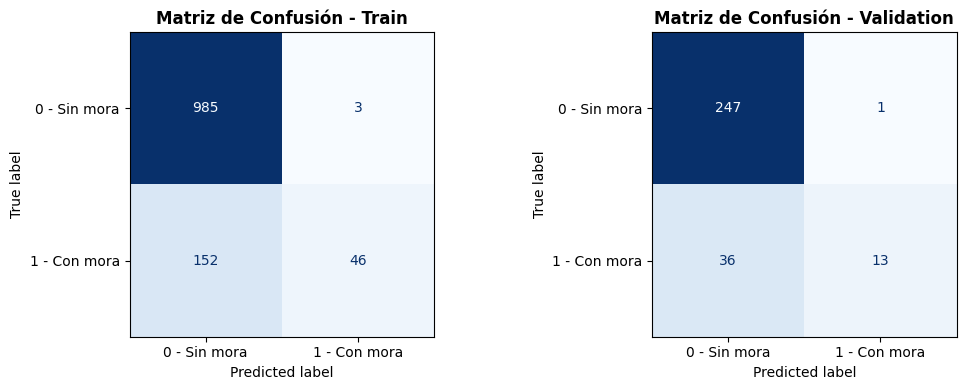

In [55]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, titulo in zip(
    axes,
    [y_train, y_val],
    [y_train_predict_best, y_val_predict_best],
    ['Matriz de Confusión - Train', 'Matriz de Confusión - Validation']
):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['0 - Sin mora', '1 - Con mora']
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False
    )

    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

Con GridSearchCV, la mejor combinación encontrada fue loss='hinge', alpha=0.001, learning_rate='optimal' y class_weight=None, con un accuracy promedio en validación cruzada de 0.8668. Además, las mejores configuraciones tuvieron baja variabilidad entre folds, con un desvío cercano a 0.016 y una varianza aproximada de 0.0003, lo que indica un comportamiento bastante estable.

Al evaluar el mejor modelo, se obtuvo un accuracy de 0.8693 en entrenamiento y 0.8754 en validación. Sin embargo, al mirar la clase 1 se observa que el recall bajó a 0.2653. Es decir, aunque el modelo tiene mejor accuracy general, solo detecta cerca del 27% de los clientes con mora.

La matriz de confusión confirma esto: en validación detectó correctamente 13 clientes con mora, pero dejó pasar 36 como si no tuvieran mora. Por lo tanto, el ajuste de hiperparámetros mejoró el accuracy, pero empeoró la capacidad del modelo para detectar la clase minoritaria.

En conclusión, como el GridSearch se optimizó usando accuracy, el modelo terminó favoreciendo a la clase mayoritaria. Por eso clasifica muy bien a los clientes sin mora, pero no resulta tan conveniente si el objetivo principal es detectar clientes con riesgo de mora.

# Árbol de decisión

Ahora vamos a repetir el análisis usando un árbol de decisión.

Este modelo tiene una interpretación diferente al clasificador lineal:

- divide el espacio de atributos mediante reglas;
- puede capturar relaciones no lineales;
- puede sobreajustar si crece demasiado.

Preguntas orientadoras:

1. ¿Qué profundidad alcanza el árbol por defecto?
2. ¿Hay evidencia de sobreajuste?
3. ¿Qué hiperparámetros podemos ajustar?
4. ¿Qué criterio conviene probar: `gini`, `entropy` o `log_loss`?
5. ¿Qué efecto tiene `max_depth`?
6. ¿Qué efecto tiene `min_samples_leaf`?


## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

# Conclusión final del trabajo práctico

Para cerrar el TP, escribamos una conclusión breve respondiendo:

1. ¿Cuál fue el mejor modelo encontrado?
2. ¿Con qué hiperparámetros?
3. ¿Qué métrica usamos para decidir?
4. ¿Por qué esa métrica es adecuada para este problema?
5. ¿El modelo parece estable entre folds?
6. ¿Hay señales de sobreajuste?
7. ¿Qué tipo de error nos preocupa más: falso positivo o falso negativo?
8. ¿Recomendaríamos usar este modelo en un contexto real? ¿Qué advertencias haríamos?

La respuesta no debería limitarse a copiar números. Debe justificar la decisión usando las métricas y el significado del problema.


# Sugerencia opcional: tabla comparativa final

Podemos resumir los resultados en una tabla como esta:

| Modelo | Mejor configuración | Accuracy test | Precision | Recall | F1 | Comentario |
|---|---|---:|---:|---:|---:|---|
| SGDClassifier | ... | ... | ... | ... | ... | ... |
| DecisionTreeClassifier | ... | ... | ... | ... | ... | ... |

Esta tabla ayuda a comparar modelos de manera ordenada.
